### 1. Fine-Tuning a Model

We first want to train, validate, and fine-tune a model using our labeled data. We will divide the labeled data into training and validation subsets, and we will also use cross-validation to get a more stable sense of model performance.

Cross-validation helps us avoid getting too excited about a lucky split of the data. By repeating training across different folds, we get a more reliable picture of how well the model is likely to perform on new texts.

> **Note:** The first time you run a Transformer model in Colab, it may take a while because the tokenizer and model weights need to be downloaded. This is normal. The notebook is not haunted.

In [1]:
####################################################################
### NO NEED TO CHANGE ANYTHING HERE UNTIL YOU GET THE HANG OF IT ###
####################################################################

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import RandomSampler, SequentialSampler

from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report

import pandas as pd
import numpy as np
import time
import datetime
import random
import os
import json

def good_update_interval(total_iters, num_desired_updates=10):
    exact_interval = total_iters / num_desired_updates
    order_of_mag = len(str(total_iters)) - 1
    round_mag = max(order_of_mag - 1, 0)
    update_interval = int(round(exact_interval, -round_mag))
    return max(update_interval, 1)

def format_time(elapsed):
    elapsed_rounded = int(round(elapsed))
    return str(datetime.timedelta(seconds=elapsed_rounded))

def print_f1_table(class_f1_dict):
    print("  ── Per-Class F1 Scores ─────────────────────────")
    for lbl, val in class_f1_dict.items():
        print(f"    {str(lbl):<20} F1: {val:.4f}")
    print("  ───────────────────────────────────────────────")

def set_seed(seed_val=6):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)
    torch.cuda.empty_cache()

set_seed(6)

Our labeled data in this example are news articles originally coded into five categories: politics, sport, tech, entertainment, and business. For the sake of a simple classroom example, I recoded political articles as `1` and a random sample of the rest as `0`.

The logic, however, is fully general. If your own dataset has three categories, seven categories, or even a continous variable, the same workflow still applies.

In [2]:
####################################################################
### YOU NEED TO IMPORT YOUR LABELED DATA HERE. CHANGE THIS CELL. ###
####################################################################

# Load your labeled data
data = pd.read_csv("/content/lang_train.csv")

# Define the key columns once and reuse them throughout the notebook
text_col = "clean_text"              # <- CHANGE THIS TO YOUR TEXT COLUMN
target_col = "label"  # <- CHANGE THIS TO YOUR LABEL COLUMN

# Quick check
print(data[[text_col, target_col]].head())
print("\nLabel counts:")
print(data[target_col].value_counts(dropna=False))

                                          clean_text  label
0  I wish to call the minister's attention to a s...      0
1  Mr.Speaker, I did not intend to take any part ...      0
2  Precisely; because it is the kind of effort th...      0
3  That, in the opinion of this house, it is most...      0
4  I do not know whether I have missed the discus...      0

Label counts:
label
0    197
1    145
Name: count, dtype: int64


In [3]:
####################################################################
### NO NEED TO CHANGE ANYTHING HERE UNTIL YOU GET THE HANG OF IT ###
####################################################################

# Shuffle data
data = data.sample(frac=1, random_state=6).reset_index(drop=True)

# Make sure target is plain Python int
data[target_col] = data[target_col].astype(int)

labels_unique = sorted(data[target_col].unique().tolist())

label2id = {str(label): int(i) for i, label in enumerate(labels_unique)}
id2label = {int(i): str(label) for i, label in enumerate(labels_unique)}

data["label"] = data[target_col].astype(str).map(label2id)

num_labels = len(label2id)

print("Detected labels:", labels_unique)
print(data["label"].value_counts())
print(label2id)
print(id2label)

Detected labels: [0, 1]
label
0    197
1    145
Name: count, dtype: int64
{'0': 0, '1': 1}
{0: '0', 1: '1'}


In [4]:
###########################################################################
### CHANGE ONLY THE TEXT COLUMN NAME ABOVE UNLESS YOU WANT A NEW MODEL. ###
###########################################################################

# Choose a tokenizer that matches your model
tokenizer = AutoTokenizer.from_pretrained("roberta-base", do_lower_case=True)

# If you want to try another model later, this is one place where you would change it.
# Example:
# tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

# Check sequence lengths before deciding on max_len
lengths = []

for _, row in data.iterrows():
    encoded_sent = tokenizer.encode(
        str(row[text_col]),
        add_special_tokens=True
    )
    lengths.append(len(encoded_sent))

print(f"{len(lengths):,} texts")
print(f"Min length: {min(lengths):,} tokens")
print(f"Max length: {max(lengths):,} tokens")
print(f"Median length: {int(np.median(lengths)):,} tokens")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (6636 > 512). Running this sequence through the model will result in indexing errors


342 texts
Min length: 4 tokens
Max length: 6,636 tokens
Median length: 616 tokens


Transformer models have a maximum input length, and longer sequences require more memory. In practice, this means we often truncate texts to a fixed maximum length.

Choosing `max_len` is therefore a tradeoff: larger values preserve more information, but require more computing power. In other words, this is where theory meets the sad reality of GPU memory, geopolitics, and resource constrains.

In [7]:
#################################################################################
### YOU CAN CHANGE max_len IF YOU WANT, BUT KEEP AN EYE ON MEMORY/RUNTIME.   ###
#################################################################################

max_len = 350  # Only for the sake of this example

num_truncated = int(np.sum(np.greater(lengths, max_len)))
num_sentences = len(lengths)
prcnt = float(num_truncated) / float(num_sentences)

print(
    "{:,} of {:,} texts ({:.1%}) are longer than {} tokens.".format(
        num_truncated, num_sentences, prcnt, max_len
    )
)

200 of 342 texts (58.5%) are longer than 350 tokens.


In [8]:
####################################################################
### TOKENIZE THE FULL DATASET AND BUILD A TensorDataset OBJECT.   ###
####################################################################

labels = []
input_ids = []
attn_masks = []

for _, row in data.iterrows():
    encoded_dict = tokenizer(
        str(row[text_col]),
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )
    input_ids.append(encoded_dict["input_ids"])
    attn_masks.append(encoded_dict["attention_mask"])
    labels.append(row["label"])

input_ids = torch.cat(input_ids, dim=0)
attn_masks = torch.cat(attn_masks, dim=0)
labels = torch.tensor(labels, dtype=torch.long)

dataset = TensorDataset(input_ids, attn_masks, labels)

print("TensorDataset ready.")
print(f"input_ids shape: {input_ids.shape}")
print(f"attention masks shape: {attn_masks.shape}")
print(f"labels shape: {labels.shape}")

TensorDataset ready.
input_ids shape: torch.Size([342, 350])
attention masks shape: torch.Size([342, 350])
labels shape: torch.Size([342])


> What are tensors? Tensors organize data in multidimensional arrays. Tensor methods organize neural network weights in a "data tensor", analyze and reduce the number of neural network weights. It helps with the computation of high-dimension matrices (e.g., word embeddings), efficiently parallelized using CUDA (NVidia), of using TPUs (Tensor Processing Units) developed by Google.

In [9]:
################################################################################
### YOU CAN PLAY WITH THESE PARAMETERS LATER.                                ###
################################################################################

model_name = "roberta-base"   # must match the tokenizer family
lr = 2e-5 # between 2e-6 and 2e-5
epochs = 2 # keep an eye on overfitting, but usually 5 is already too much
batch_size = 16 # better if increased by 2^n
num_labels = len(labels_unique)

print({
    "model_name": model_name,
    "lr": lr,
    "epochs": epochs,
    "batch_size": batch_size,
    "num_labels": num_labels
})

{'model_name': 'roberta-base', 'lr': 2e-05, 'epochs': 2, 'batch_size': 16, 'num_labels': 2}


In [10]:
####################################################################
### NO NEED TO CHANGE ANYTHING HERE UNTIL YOU GET THE HANG OF IT ###
####################################################################

set_seed(6)

fold_stats = []
total_t0 = time.time()

To determine which hyperparameters to use and to evaluate model performance, we use cross-validation (CV). The data are divided into $k$ folds. In each run, one fold is held out for validation while the remaining $k-1$ folds are used for training. This process repeats until every fold has served as the validation fold once.

The main idea is simple: performance should not depend too much on one lucky or unlucky split of the data.

For this example, we will use only two folds to keep the runtime manageable in class. In real work, you would often use more (ten is common).

In [11]:
###########################################################################
### CHANGE ONLY k_folds IF YOU WANT TO RUN MORE OR FEWER CV ITERATIONS. ###
###########################################################################

k_folds = 8
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=6)

timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H%M")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for fold, (train_ids, test_ids) in enumerate(kfold.split(dataset)):
    print(f"\n======== Fold {fold + 1} / {k_folds} ========")

    train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
    test_subsampler = torch.utils.data.SubsetRandomSampler(test_ids)

    train_dataloader = DataLoader(dataset, batch_size=batch_size, sampler=train_subsampler)
    test_dataloader = DataLoader(dataset, batch_size=batch_size, sampler=test_subsampler)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    )
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, eps=1e-6)
    total_steps = len(train_dataloader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=10,
        num_training_steps=total_steps
    )

    best_val_loss = float("inf")
    patience = 2
    patience_counter = 0

    for epoch_i in range(epochs):
        print(f"\nEpoch {epoch_i + 1}/{epochs}")
        model.train()
        total_train_loss = 0
        t0 = time.time()

        update_interval = good_update_interval(len(train_dataloader), 10)

        for step, batch in enumerate(train_dataloader):
            if step % update_interval == 0 and step != 0:
                print(f"  Batch {step} of {len(train_dataloader)} ...")

            b_input_ids, b_input_mask, b_labels = [x.to(device) for x in batch]
            model.zero_grad()

            outputs = model(
                b_input_ids,
                attention_mask=b_input_mask,
                labels=b_labels
            )
            loss = outputs.loss
            total_train_loss += loss.item()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        avg_train_loss = total_train_loss / len(train_dataloader)
        training_time = format_time(time.time() - t0)

        model.eval()
        total_eval_loss = 0
        preds, trues = [], []

        for batch in test_dataloader:
            b_input_ids, b_input_mask, b_labels = [x.to(device) for x in batch]

            with torch.no_grad():
                outputs = model(
                    b_input_ids,
                    attention_mask=b_input_mask,
                    labels=b_labels
                )

            loss = outputs.loss
            logits = outputs.logits

            total_eval_loss += loss.item()
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            trues.extend(b_labels.cpu().numpy())

        avg_val_loss = total_eval_loss / len(test_dataloader)
        acc = accuracy_score(trues, preds)
        f1_weighted = f1_score(trues, preds, average="weighted")

        per_class_f1 = f1_score(
            trues,
            preds,
            average=None,
            labels=list(range(num_labels))
        )
        class_f1_dict = {id2label[i]: float(per_class_f1[i]) for i in range(num_labels)}

        print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"  Accuracy: {acc:.4f} | Weighted F1: {f1_weighted:.4f}")
        print_f1_table(class_f1_dict)
        print(f"  Time: {training_time}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"  Validation loss did not improve. Patience {patience_counter}/{patience}.")

        fold_record = {
            "fold": fold + 1,
            "Train Loss": avg_train_loss,
            "Val Loss": avg_val_loss,
            "Accuracy": acc,
            "Weighted F1": f1_weighted
        }
        fold_record.update({f"F1_{lbl}": val for lbl, val in class_f1_dict.items()})
        fold_stats.append(fold_record)


======== Fold 1 / 8 ========


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/2
  Batch 2 of 19 ...
  Batch 4 of 19 ...
  Batch 6 of 19 ...
  Batch 8 of 19 ...
  Batch 10 of 19 ...
  Batch 12 of 19 ...
  Batch 14 of 19 ...
  Batch 16 of 19 ...
  Batch 18 of 19 ...
  Train Loss: 0.6927 | Val Loss: 0.6575
  Accuracy: 0.6279 | Weighted F1: 0.4844
  ── Per-Class F1 Scores ─────────────────────────
    0                    F1: 0.7714
    1                    F1: 0.0000
  ───────────────────────────────────────────────
  Time: 0:00:18

Epoch 2/2
  Batch 2 of 19 ...
  Batch 4 of 19 ...
  Batch 6 of 19 ...
  Batch 8 of 19 ...
  Batch 10 of 19 ...
  Batch 12 of 19 ...
  Batch 14 of 19 ...
  Batch 16 of 19 ...
  Batch 18 of 19 ...
  Train Loss: 0.6617 | Val Loss: 0.6305
  Accuracy: 0.6512 | Weighted F1: 0.5352
  ── Per-Class F1 Scores ─────────────────────────
    0                    F1: 0.7826
    1                    F1: 0.1176
  ───────────────────────────────────────────────
  Time: 0:00:17

======== Fold 2 / 8 ========


...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/2
  Batch 2 of 19 ...
  Batch 4 of 19 ...
  Batch 6 of 19 ...
  Batch 8 of 19 ...
  Batch 10 of 19 ...
  Batch 12 of 19 ...
  Batch 14 of 19 ...
  Batch 16 of 19 ...
  Batch 18 of 19 ...
  Train Loss: 0.6832 | Val Loss: 0.6801
  Accuracy: 0.5476 | Weighted F1: 0.3875
  ── Per-Class F1 Scores ─────────────────────────
    0                    F1: 0.7077
    1                    F1: 0.0000
  ───────────────────────────────────────────────
  Time: 0:00:20

Epoch 2/2
  Batch 2 of 19 ...
  Batch 4 of 19 ...
  Batch 6 of 19 ...
  Batch 8 of 19 ...
  Batch 10 of 19 ...
  Batch 12 of 19 ...
  Batch 14 of 19 ...
  Batch 16 of 19 ...
  Batch 18 of 19 ...
  Train Loss: 0.6569 | Val Loss: 0.6628
  Accuracy: 0.5476 | Weighted F1: 0.3875
  ── Per-Class F1 Scores ─────────────────────────
    0                    F1: 0.7077
    1                    F1: 0.0000
  ───────────────────────────────────────────────
  Time: 0:00:20

======== Fold 8 / 8 ========


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/2
  Batch 2 of 19 ...
  Batch 4 of 19 ...
  Batch 6 of 19 ...
  Batch 8 of 19 ...
  Batch 10 of 19 ...
  Batch 12 of 19 ...
  Batch 14 of 19 ...
  Batch 16 of 19 ...
  Batch 18 of 19 ...
  Train Loss: 0.6889 | Val Loss: 0.6861
  Accuracy: 0.5238 | Weighted F1: 0.3601
  ── Per-Class F1 Scores ─────────────────────────
    0                    F1: 0.6875
    1                    F1: 0.0000
  ───────────────────────────────────────────────
  Time: 0:00:20

Epoch 2/2
  Batch 2 of 19 ...
  Batch 4 of 19 ...
  Batch 6 of 19 ...
  Batch 8 of 19 ...
  Batch 10 of 19 ...
  Batch 12 of 19 ...
  Batch 14 of 19 ...
  Batch 16 of 19 ...
  Batch 18 of 19 ...
  Train Loss: 0.6795 | Val Loss: 0.6854
  Accuracy: 0.5238 | Weighted F1: 0.3601
  ── Per-Class F1 Scores ─────────────────────────
    0                    F1: 0.6875
    1                    F1: 0.0000
  ───────────────────────────────────────────────
  Time: 0:00:21


### How to read the loss values

- **Validation loss much larger than training loss** usually suggests overfitting.
- **Validation loss slightly larger than training loss** is common and often fine.
- **Training and validation loss both high** usually suggests underfitting or weak settings.
- **The main goal** is not to get the training loss to look heroic; it is to get good validation performance.

Also, for imbalanced classification tasks, weighted F1 is often more informative than accuracy alone. You can check the meaning of each stat, how to interpret them, and when to use them, in scholarly journal [Wikipedia](https://en.wikipedia.org/wiki/Precision_and_recall), or check out [this paper](https://d1wqtxts1xzle7.cloudfront.net/37219940/5215ijdkp01-libre.pdf?1428316763=&response-content-disposition=inline%3B+filename%3DA_REVIEW_ON_EVALUATION_METRICS_FOR_DATA.pdf&Expires=1709137264&Signature=f3EFHnlTZXa38ug6~VBumSZrfe9ECAyMUh04CNTzYnXEsVaJS3T12eNPbu7iNP~z3DSTTJ2NAV845v50XBe8Sjm7AylacfjGxcQ8YqaDsMulhkCV8c-JtTrWaLILlSUzbQp9M5Md3ubChx5Y9xkBp~s~XlecEEu9B5QEOjyr2aiZRA6gz98crSv0VKKV2ow986UxoSaWZgaYPmTsTrWU2EN3-0S1~OyO9tf2eFqbb3jUwOl15vX1rzzoG9lcpqbURB0eGMqPlXoWPHYBAlGmvUJOGxfkz15VpCxYtg-RoL5IYJONHlkV8GDWXntOm4WdY-ZIcgF3f3c7XhpDzgzvGw__&Key-Pair-Id=APKAJLOHF5GGSLRBV4ZA).


We can now inspect the fold-level output and summarize performance across folds. This is where we stop admiring the model's confidence and start asking whether it actually deserves that confidence.

In [12]:
folds_df = pd.DataFrame(fold_stats)
folds_df

,fold,Train Loss,Val Loss,Accuracy,Weighted F1,F1_0,F1_1
0,1,0.692722,0.657470,0.627907,0.484385,0.771429,0.000000
1,1,0.661716,0.630460,0.651163,0.535181,0.782609,0.117647
2,2,0.697169,0.694147,0.488372,0.320494,0.656250,0.000000
3,2,0.677116,0.679564,0.488372,0.320494,0.656250,0.000000
4,3,0.693589,0.658734,0.674419,0.543282,0.805556,0.000000
5,3,0.673443,0.630617,0.674419,0.543282,0.805556,0.000000
6,4,0.678306,0.671488,0.581395,0.427497,0.735294,0.000000
7,4,0.665554,0.633414,0.627907,0.524172,0.757576,0.200000
8,5,0.687253,0.677377,0.558140,0.399861,0.716418,0.000000
9,5,0.650371,0.652212,0.604651,0.496328,0.738462,0.190476


In [13]:
results_summary = {
    "Model": model_name,
    "LR": lr,
    "Epochs": epochs,
    "Batch Size": batch_size,
    "Mean Acc": float(np.mean([f["Accuracy"] for f in fold_stats])),
    "SD Acc": float(np.std([f["Accuracy"] for f in fold_stats])),
    "Mean Weighted F1": float(np.mean([f["Weighted F1"] for f in fold_stats])),
    "SD Weighted F1": float(np.std([f["Weighted F1"] for f in fold_stats]))
}

for lbl in labels_unique:
    f1_vals = [f[f"F1_{lbl}"] for f in fold_stats if f"F1_{lbl}" in f]
    results_summary[f"Mean F1_{lbl}"] = float(np.mean(f1_vals))
    results_summary[f"SD F1_{lbl}"] = float(np.std(f1_vals))

summary_df = pd.DataFrame([results_summary])
summary_df

,Model,LR,Epochs,Batch Size,Mean Acc,SD Acc,Mean Weighted F1,SD Weighted F1,Mean F1_0,SD F1_0,Mean F1_1,SD F1_1
0,roberta-base,0.00002,2,16,0.590324,0.067332,0.451061,0.094492,0.736369,0.049464,0.060167,0.122171


In [14]:
print("Per-fold records:")
print(folds_df)

print("\nAggregate summary:")
print(summary_df)

Per-fold records:
    fold  Train Loss  Val Loss  Accuracy  Weighted F1      F1_0      F1_1
0      1    0.692722  0.657470  0.627907     0.484385  0.771429  0.000000
1      1    0.661716  0.630460  0.651163     0.535181  0.782609  0.117647
2      2    0.697169  0.694147  0.488372     0.320494  0.656250  0.000000
3      2    0.677116  0.679564  0.488372     0.320494  0.656250  0.000000
4      3    0.693589  0.658734  0.674419     0.543282  0.805556  0.000000
5      3    0.673443  0.630617  0.674419     0.543282  0.805556  0.000000
6      4    0.678306  0.671488  0.581395     0.427497  0.735294  0.000000
7      4    0.665554  0.633414  0.627907     0.524172  0.757576  0.200000
8      5    0.687253  0.677377  0.558140     0.399861  0.716418  0.000000
9      5    0.650371  0.652212  0.604651     0.496328  0.738462  0.190476
10     6    0.684051  0.669426  0.604651     0.455679  0.753623  0.000000
11     6    0.666335  0.655435  0.720930     0.670983  0.812500  0.454545
12     7    0.683188

All right, now that the model seems to know what it is doing, we can train a final version using the labeled dataset and save it for later use.

Instead of training blindly on everything and hoping for the best, we will still keep a small validation split during this final training step. That gives us one more check before saving the model.


In [15]:
#######################################################################
### FINAL TRAINING: TRAIN/VALIDATION SPLIT + MODEL/METADATA SAVING. ###
#######################################################################

from sklearn.model_selection import train_test_split # Added this import

# Train/validation split
train_inputs, val_inputs, train_masks, val_masks, train_labels, val_labels = train_test_split(
    input_ids,
    attn_masks,
    labels,
    test_size=0.10,
    random_state=6,
    stratify=labels
)

train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
val_dataset   = TensorDataset(val_inputs, val_masks, val_labels)

train_dataloader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),
    batch_size=batch_size
)

validation_dataloader = DataLoader(
    val_dataset,
    sampler=SequentialSampler(val_dataset),
    batch_size=batch_size
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, eps=1e-6)
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=10,
    num_training_steps=total_steps
)

total_t0 = time.time()

for epoch_i in range(epochs):
    print(f"\n======== Epoch {epoch_i + 1} / {epochs} ========")

    model.train()
    total_train_loss = 0
    t0 = time.time()

    update_interval = good_update_interval(len(train_dataloader), 10)

    for step, batch in enumerate(train_dataloader):
        if step % update_interval == 0 and step != 0:
            print(f"  Batch {step} of {len(train_dataloader)} ...")

        b_input_ids, b_input_mask, b_labels = [x.to(device) for x in batch]

        model.zero_grad()

        outputs = model(
            b_input_ids,
            attention_mask=b_input_mask,
            labels=b_labels
        )
        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    training_time = format_time(time.time() - t0)

    print(f"  Average training loss: {avg_train_loss:.4f}")
    print(f"  Training epoch took: {training_time}")

    model.eval()
    total_eval_loss = 0
    preds, trues = [], []

    for batch in validation_dataloader:
        b_input_ids, b_input_mask, b_labels = [x.to(device) for x in batch]

        with torch.no_grad():
            outputs = model(
                b_input_ids,
                attention_mask=b_input_mask,
                labels=b_labels
            )

        loss = outputs.loss
        logits = outputs.logits

        total_eval_loss += loss.item()
        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        trues.extend(b_labels.cpu().numpy())

    avg_val_loss = total_eval_loss / len(validation_dataloader)
    acc = accuracy_score(trues, preds)
    f1_weighted = f1_score(trues, preds, average="weighted")

    print(f"  Validation Loss: {avg_val_loss:.4f}")
    print(f"  Validation Accuracy: {acc:.4f}")
    print(f"  Validation Weighted F1: {f1_weighted:.4f}")

total_training_time = format_time(time.time() - total_t0)
print(f"\nTraining complete in {total_training_time}.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



======== Epoch 1 / 2 ========
  Batch 2 of 20 ...
  Batch 4 of 20 ...
  Batch 6 of 20 ...
  Batch 8 of 20 ...
  Batch 10 of 20 ...
  Batch 12 of 20 ...
  Batch 14 of 20 ...
  Batch 16 of 20 ...
  Batch 18 of 20 ...
  Average training loss: 0.7009
  Training epoch took: 0:00:19
  Validation Loss: 0.6758
  Validation Accuracy: 0.5714
  Validation Weighted F1: 0.4156

======== Epoch 2 / 2 ========
  Batch 2 of 20 ...
  Batch 4 of 20 ...
  Batch 6 of 20 ...
  Batch 8 of 20 ...
  Batch 10 of 20 ...
  Batch 12 of 20 ...
  Batch 14 of 20 ...
  Batch 16 of 20 ...
  Batch 18 of 20 ...
  Average training loss: 0.6793
  Training epoch took: 0:00:19
  Validation Loss: 0.6740
  Validation Accuracy: 0.5714
  Validation Weighted F1: 0.4156

Training complete in 0:00:39.


[[20  0]
 [15  0]]


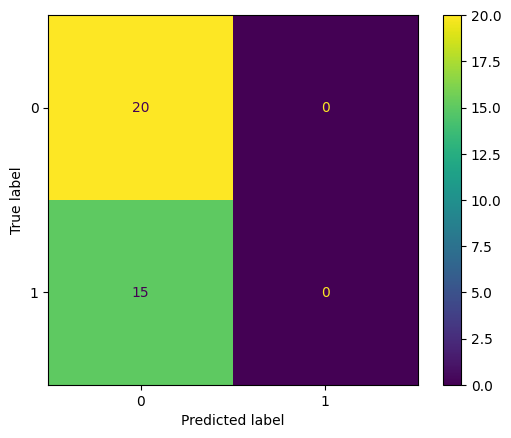

              precision    recall  f1-score   support

           0     0.5714    1.0000    0.7273        20
           1     0.0000    0.0000    0.0000        15

    accuracy                         0.5714        35
   macro avg     0.2857    0.5000    0.3636        35
weighted avg     0.3265    0.5714    0.4156        35



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

all_preds = []
all_labels = []

for batch in validation_dataloader:
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_labels = batch[2].to(device)

    with torch.no_grad():
        outputs = model(
            b_input_ids,
            token_type_ids=None,
            attention_mask=b_input_mask
        )

    logits = outputs.logits
    preds = torch.argmax(logits, dim=1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(b_labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print(classification_report(all_labels, all_preds, digits=4))

In [ ]:
plt.savefig("afford_confusion_matrix.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [17]:
####################################################################
### SAVE MODEL, TOKENIZER, AND LABEL MAPS FOR FUTURE PREDICTION. ###
####################################################################

save_dir = "my_fine_tuned_classifier"   # <- CHANGE THIS FOLDER NAME IF YOU WANT
os.makedirs(save_dir, exist_ok=True)

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

meta = {
    "label2id": label2id,
    "id2label": id2label,
    "model_name": model_name,
    "max_len": max_len,
    "lr": lr,
    "epochs": epochs,
    "batch_size": batch_size,
    "num_labels": num_labels,
    "text_col": text_col,
    "target_col": target_col
}

meta_row = meta.copy()
meta_row["label2id"] = json.dumps(meta_row["label2id"], ensure_ascii=False)
meta_row["id2label"] = json.dumps(meta_row["id2label"], ensure_ascii=False)

meta_df = pd.DataFrame([meta_row])
meta_csv = os.path.join(save_dir, "model_meta.csv")
meta_df.to_csv(meta_csv, index=False)

print(f"Model saved to: {save_dir}")
print(f"Metadata saved to: {meta_csv}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: my_fine_tuned_classifier
Metadata saved to: my_fine_tuned_classifier/model_meta.csv


Why save `label2id` and `id2label`?

Because once the model is trained, you still need to know which output index corresponds to which class (labels are changed to numeric ids). Saving those mappings makes your model reusable and reproducible. Without them, you have an output `2`, but you will not be sure what `2` means.

### 3. Using the Model

To use the model later, we load the saved model, tokenizer, and metadata. Then we can classify new text.

Below is a student-friendly version that returns the predicted label and a confidence score. Confidence is not the same thing as correctness, but it is still useful information.

In [18]:
# If this were a new session, this is how you would load everything back in.

from transformers import AutoTokenizer, AutoModelForSequenceClassification

load_dir = save_dir
meta_df = pd.read_csv(os.path.join(load_dir, "model_meta.csv"))
meta = meta_df.iloc[0].to_dict()

label2id_loaded = json.loads(meta["label2id"])
id2label_loaded = json.loads(meta["id2label"])

label2id_loaded = {k: int(v) for k, v in label2id_loaded.items()}
id2label_loaded = {int(k): v for k, v in id2label_loaded.items()}

max_len_loaded = int(meta["max_len"])
num_labels_loaded = int(meta["num_labels"])

tokenizer_loaded = AutoTokenizer.from_pretrained(load_dir)
my_model = AutoModelForSequenceClassification.from_pretrained(
    load_dir,
    num_labels=num_labels_loaded,
    id2label=id2label_loaded,
    label2id=label2id_loaded
)

inference_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
my_model.to(inference_device)
my_model.eval()

def predict(text, model=my_model, tokenizer=tokenizer_loaded, id2label=id2label_loaded, max_len=max_len_loaded):
    enc = tokenizer(
        str(text),
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_len
    )

    input_ids = enc["input_ids"].to(inference_device)
    attention_mask = enc["attention_mask"].to(inference_device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

    probs = torch.softmax(outputs.logits, dim=-1)
    pred_id = torch.argmax(probs, dim=-1).item()
    confidence = torch.max(probs, dim=-1).values.item()

    return {
        "predicted_id": pred_id,
        "predicted_label": id2label[pred_id],
        "confidence": confidence
    }

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

And here is some code to loop through a corpus more neatly so you can pass a larger dataset through your fine-tuned model.


In [19]:

import pandas as pd

target_df = pd.read_csv("/content/education_speeches.csv")
print(target_df.shape)
print(target_df.columns)
target_df.head()


from tqdm import tqdm

target_df["clean_text"] = target_df["clean_text"].fillna("")

predictions = []
for text in tqdm(target_df["clean_text"]):
    predictions.append(predict(text))

pred_df = pd.DataFrame(predictions)

out_df = pd.concat([target_df.reset_index(drop=True), pred_df], axis=1)

out_df = out_df.rename(columns={
    "predicted_id": "lang_pred_id",
    "predicted_label": "lang_pred",
    "confidence": "lang_conf"
})

print(out_df.shape)
out_df.head()

(57261, 23)
Index(['basepk', 'hid', 'speechdate', 'pid', 'opid', 'speakeroldname',
       'speakerposition', 'maintopic', 'subtopic', 'subsubtopic',
       'speakerparty', 'speakerriding', 'speakername', 'speakerurl',
       'speech_date', 'year', 'month', 'day', 'weekday', 'source_file',
       'source_path', 'speechmonth', 'clean_text'],
      dtype='object')


100%|██████████| 57261/57261 [20:46<00:00, 45.92it/s]


(57261, 26)


,basepk,hid,speechdate,pid,opid,speakeroldname,speakerposition,maintopic,subtopic,subsubtopic,...,month,day,weekday,source_file,source_path,speechmonth,clean_text,lang_pred_id,lang_pred,lang_conf
0,228,ca.proc.d.1901-02-12.4.19.1,1901-02-12,unmatched,NaN,NaN,NaN,QUESTIONS.,"SCHOOL LANDS, MANITOBA-SALES BY AUCTION.",NaN,...,2,12,Tuesday,1901-2-12.csv,C:/Users/KaylynnTemp/Documents/Winter2026PhD/T...,1901-02-01,LaRIVIERE (Provencher) moved for:\t.List of sc...,0,0,0.560495
1,315,ca.proc.d.1901-02-14.18.1,1901-02-14,unmatched,NaN,NaN,NaN,MANITOBA SCHOOL LANDS.,NaN,NaN,...,2,14,Thursday,1901-2-14.csv,C:/Users/KaylynnTemp/Documents/Winter2026PhD/T...,1901-02-01,LaRIVIERE (Provencher) moved for :.opy of all ...,0,0,0.554128
2,645,ca.proc.d.1901-02-19.5.2.36,1901-02-19,2a8c7330-53c3-44dc-9f77-c16aa6af7898,ca.m.2417,Mr. HENRI BOTJRASSA (Labelle).,NaN,SUPPLY-THE RAILWAY QUESTION.,NaN,NaN,...,2,19,Tuesday,1901-2-19.csv,C:/Users/KaylynnTemp/Documents/Winter2026PhD/T...,1901-02-01,It is to be regretted that the hon.member for ...,0,0,0.558688
3,642,ca.proc.d.1901-02-19.5.2.33,1901-02-19,d1344229-2345-4b79-acda-cb584ec7cc68,ca.m.2854,Mr. MONK.,NaN,SUPPLY-THE RAILWAY QUESTION.,NaN,NaN,...,2,19,Tuesday,1901-2-19.csv,C:/Users/KaylynnTemp/Documents/Winter2026PhD/T...,1901-02-01,A strong delegation of the government went ove...,0,0,0.561665
4,1764,ca.proc.d.1901-02-25.33.19,1901-02-25,7b93f979-f291-49f1-9a5c-54d08800f177,ca.m.2348,Mr. SPROULE.,NaN,BEET-ROOT SUGAR BOUNTY.,NaN,NaN,...,2,25,Monday,1901-2-25.csv,C:/Users/KaylynnTemp/Documents/Winter2026PhD/T...,1901-02-01,The industry failed.I | was going to say one w...,0,0,0.562264


In [20]:
out_df.to_csv("/content/lang_predictions.csv", index=False)